<a href="https://colab.research.google.com/github/anulax1114-design/PRAC1-st20347210-DA/blob/main/DA_PRAC_1.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

#**INTRODUCTION**
---

**Overview**
-----
Apart from land and water, air is one of the most essential resources for life. However, air pollution remains one of the most serious environmental challenges worldwide. Cities like Beijing have experienced significant air quality issues due to rapid urbanisation, industrial activities, and increasing vehicle emissions. Monitoring and analysing air pollution levels is therefore important to understand its impact on public health and environmental sustainability.

With advancements in technology, large volumes of air quality data are continuously collected from monitoring stations. This data provides valuable insights into pollution levels and helps researchers and policymakers make informed decisions. In this project, programming and data analysis techniques are used to explore, analyse, and model air quality data from Beijing.

**What is Air Quality Index (AQI) and why is it needed?**

Air quality is measured using different pollutants such as PM2.5, PM10, SO₂, NO₂, CO, and O₃. However, interpreting multiple pollutant values can be complex and difficult to understand for the general public.

To simplify this, the Air Quality Index (AQI) was developed. AQI converts complex air pollution data into a single value and category (such as “Good”, “Moderate”, or “Poor”), making it easier for people to understand the quality of air and take necessary precautions.

AQI is important because:

•	It provides a simple way to communicate air pollution level.

•	It helps individuals, especially those with health issues, make informed decisions

•	It supports governments in planning and implementing pollution control measures

**What this Dataset is about**

This dataset is used to analyse and understand air quality patterns in Beijing. It consists of hourly observations collected from multiple monitoring stations between March 2013 and February 2017.

**For this study, four stations were selected:**

•	Urban stations: Dongsi and Guanyuan

•	Suburban stations: Shunyi and Huairou

**Why this datasets were Chosen**

***Dongsi and Guanyuan — Inner Urban Stations***

Dongsi (Chaoyang district) and Guanyuan (Xicheng district) are both classified as urban stations situated inside the fourth ring road of Beijing. Yao et al. (2015) applied cluster analysis to all 12 stations and found that urban stations form distinct clusters with the highest average PM2.5 concentrations, driven by dense residential activity, commercial traffic and road emissions. Xu and Zhang (2020) further confirm that urban areas in south Beijing consistently recorded higher PM2.5 levels than suburban sites at every hour of the day, every day of the week and every month of the year. Selecting stations from two different urban districts — east and west of the city centre — also ensures spatial diversity within the urban zone, avoiding geographic bias.

***Huairou and Shunyi — Outer Suburban Stations***

Huairou (north-west) and Shunyi (north-east) are both officially classified as suburban stations in the outer ring of Beijing. Yao et al. (2015) demonstrate that suburban stations form a separate cluster with meaningfully lower PM2.5 averages, with the outermost stations recording the minimum pollution values across the entire network. Batterman et al. (2016) further report that annual average PM2.5 concentrations varied by up to 20 µg/m³ across the study area, with suburban sites showing consistently lower readings than urban and peri-urban zones — differences associated with higher vegetation cover and lower construction and traffic activity. Selecting Huairou and Shunyi from opposite sides of the suburban ring also provides geographic spread, ensuring the suburban signal is not localised to one direction.

**Why This Combination Is Analytically Strongest**

Yao et al. (2015) demonstrate that the correlation between urban and suburban stations is generally below 0.85, confirming that these two groups capture genuinely different pollution dynamics rather than redundant measurements. This contrast is essential for the EDA tasks in this assessment, where comparing station types is a core objective. The urban–suburban gradient captured by these four stations also directly supports the model building task, as station type becomes a meaningful predictive feature for PM2.5 concentration — consistent with the data-driven approach to pollution monitoring advocated by Sokhi et al. (2022), Xu and Zhang (2020) and Batterman et al. (2016).

The dataset includes:

Air Pollutants

•	PM2.5, PM10

•	SO₂, NO₂, CO, O₃

Meteorological Factors

•	Temperature (Temp)

•	Dew Point (Dewp)

•	Pressure (Pres)

•	Wind Speed (Wspd)

•	Rainfall (Rain)

By analysing this dataset, the project aims to identify pollution patterns, seasonal trends, and differences between urban and suburban areas. Using programming and data analytics tools, the raw data is transformed into meaningful insights that support environmental understanding and decision-making.

**Research Questions**

•	Which pollutants have the greatest influence on PM2.5 levels in Beijing?

•	How do meteorological factors affect air pollution levels?

•	What seasonal and long-term trends can be observed in air quality?

•	Can machine learning models accurately predict PM2.5 levels using historical data?

•	How does model performance vary across different monitoring stations?



### **Import The Necessary Libraries**

In [12]:
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
import numpy as np
import seaborn as sns
from sklearn import preprocessing
import warnings
warnings.filterwarnings('ignore')
%matplotlib inline

**GIT Cloning**

In [13]:
! git config --global user.name "anulax1114-design"
! git config --global user.email "anulax1114@gmail.com"

In [14]:
username = "anulax1114-design"
repo = "PRAC1-st20347210-DA"

In [15]:
! git clone https://@github.com/{username}/{repo}

fatal: destination path 'PRAC1-st20347210-DA' already exists and is not an empty directory.


In [16]:
%cd {repo}

/content/PRAC1-st20347210-DA/PRAC1-st20347210-DA


In [17]:
%ls

beijing_merged_data.csv
DA_PRAC_1.ipynb
PRAC1-st20347210-DA/
PRSA_Data_Dongsi_20130301-20170228.csv
PRSA_Data_Guanyuan_20130301-20170228.csv
PRSA_Data_Huairou_20130301-20170228.csv
PRSA_Data_Shunyi_20130301-20170228.csv


**Merging of the csv Files**

In [18]:
# Import required libraries
import pandas as pd   # Used for data handling
import glob           # Used to find files
import os             # Used to check directory

# STEP 1: Check current working directory
print(f"Current working directory: {os.getcwd()}")

# STEP 2: Find all Beijing dataset CSV files
csv_files = glob.glob("PRSA_Data_*.csv")

# Create an empty list to store datasets
all_data = []

# STEP 3: Load each dataset
if not csv_files:
    print("No dataset files found. Please check your folder.")
else:
    for file in csv_files:
        # Read CSV file
        df = pd.read_csv(file)

        # Extract station name from file name
        station_name = file.split("_")[2]

        # Add station column
        df["station"] = station_name

        # Append to list
        all_data.append(df)

        print(f"Loaded: {station_name}")

# STEP 4: Merge all datasets into one
if all_data:
    combined_df = pd.concat(all_data, ignore_index=True)

    # Save merged dataset
    combined_df.to_csv("beijing_merged_data.csv", index=False)

    print(f"Successfully merged {len(csv_files)} datasets.")
    print(f"Total rows: {len(combined_df)}")
else:
    print("No data to merge.")

Current working directory: /content/PRAC1-st20347210-DA/PRAC1-st20347210-DA
Loaded: Huairou
Loaded: Dongsi
Loaded: Guanyuan
Loaded: Shunyi
Successfully merged 4 datasets.
Total rows: 140256


Datasets from the selected Beijing monitoring stations (Dongsi, Guanyuan, Shunyi, and Huairou) were imported using Pandas and combined into a single dataset. A ‘station’ column was added to each dataset prior to merging to retain the source of each observation. The datasets were then concatenated into a unified DataFrame, ensuring a consistent structure for analysis. This approach preserves station-level information, enabling effective comparison of air quality across different locations. The final merged dataset was saved for subsequent preprocessing and analysis.

##**Loading the Pandas Dataframe:**

In [19]:

# Load the merged Beijing dataset into a DataFrame
df = pd.read_csv("beijing_merged_data.csv")
df

,No,year,month,day,hour,PM2.5,PM10,SO2,NO2,CO,O3,TEMP,PRES,DEWP,RAIN,wd,WSPM,station
0,1,2013,3,1,0,7.0,7.0,3.0,2.0,100.0,91.0,-2.3,1020.3,-20.7,0.0,WNW,3.1,Huairou
1,2,2013,3,1,1,4.0,4.0,3.0,NaN,100.0,92.0,-2.7,1020.8,-20.5,0.0,NNW,1.5,Huairou
2,3,2013,3,1,2,4.0,4.0,NaN,NaN,100.0,91.0,-3.2,1020.6,-21.4,0.0,NW,1.8,Huairou
3,4,2013,3,1,3,3.0,3.0,3.0,2.0,NaN,NaN,-3.3,1021.3,-23.7,0.0,NNW,2.4,Huairou
4,5,2013,3,1,4,3.0,3.0,7.0,NaN,300.0,86.0,-4.1,1022.1,-22.7,0.0,NNW,2.2,Huairou
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
140251,35060,2017,2,28,19,27.0,72.0,8.0,92.0,800.0,16.0,10.3,1014.2,-12.4,0.0,W,1.8,Shunyi
140252,35061,2017,2,28,20,47.0,55.0,17.0,86.0,1100.0,19.0,9.8,1014.5,-9.9,0.0,NW,1.5,Shunyi
140253,35062,2017,2,28,21,18.0,28.0,4.0,30.0,500.0,64.0,9.1,1014.6,-12.7,0.0,NE,1.7,Shunyi
140254,35063,2017,2,28,22,18.0,20.0,9.0,33.0,500.0,59.0,7.1,1015.2,-13.2,0.0,WNW,1.8,Shunyi


**Description of Dataset Columns**

The dataset contains hourly air quality and meteorological measurements collected from multiple monitoring stations in Beijing. The key variables included are:

*  PM2.5 – Fine particulate matter smaller than 2.5 micrometres, which can penetrate deep into the lungs and pose serious health risks.

*  PM10 – Particulate mattersmaller than 10 micrometres, commonly originating from dust and combustion processes.

*  SO₂ (Sulfur Dioxide) – A gas mainly produced from burning fossil fuels, contributing to respiratory problems and acid rain.

* NO₂ (Nitrogen Dioxide) – A harmful gas emitted from vehicles and industrial activities, associated with respiratory issues.

*  CO (Carbon Monoxide) – A colourless, toxic gas formed due to incomplete combustion of fuels.

*  O₃ (Ozone) – A secondary pollutant formed through chemical reactions in sunlight, harmful at ground level.

**Meteorological Variables**


* TEMP (Temperature) - Measures atmospheric temperature, which influences pollutant dispersion.

* DEWP (Dew Point) - Indicates moisture content in the air.

* PRES (Pressure) - Atmospheric pressure, affecting air movement and pollution concentration.

* WSPM (Wind Speed) - Wind speed, which plays a key role in dispersing pollutants.

* RAIN (Rainfall) - Precipitation that can reduce pollution levels by washing out particles.

**Time and Station Information**


* year, month, day, hour - Time-related variables representing when each observation was recorded.


* station - Identifies the monitoring station (Dongsi, Guanyuan, Shunyi, or Huairou), enabling comparison across locations.

##**Exploratory Data Analysis**

In [20]:
df.shape

(140256, 18)

In [21]:
df.columns

Index(['No', 'year', 'month', 'day', 'hour', 'PM2.5', 'PM10', 'SO2', 'NO2',
       'CO', 'O3', 'TEMP', 'PRES', 'DEWP', 'RAIN', 'wd', 'WSPM', 'station'],
      dtype='object')

In [22]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 140256 entries, 0 to 140255
Data columns (total 18 columns):
 #   Column   Non-Null Count   Dtype  
---  ------   --------------   -----  
 0   No       140256 non-null  int64  
 1   year     140256 non-null  int64  
 2   month    140256 non-null  int64  
 3   day      140256 non-null  int64  
 4   hour     140256 non-null  int64  
 5   PM2.5    137024 non-null  float64
 6   PM10     137949 non-null  float64
 7   SO2      136843 non-null  float64
 8   NO2      134992 non-null  float64
 9   CO       131706 non-null  float64
 10  O3       135779 non-null  float64
 11  TEMP     140114 non-null  float64
 12  PRES     140112 non-null  float64
 13  DEWP     140109 non-null  float64
 14  RAIN     140110 non-null  float64
 15  wd       139312 non-null  object 
 16  WSPM     140135 non-null  float64
 17  station  140256 non-null  object 
dtypes: float64(11), int64(5), object(2)
memory usage: 19.3+ MB


**Number of Records in Each station**

In [23]:
# Count number of records for each station
stations = df['station'].value_counts()

# Total number of stations
print(f"Total number of stations in the dataset: {len(stations)}")

# Display station-wise counts
stations

Total number of stations in the dataset: 4


,count
station,
Huairou,35064
Dongsi,35064
Guanyuan,35064
Shunyi,35064


In [25]:
df['station'].nunique()

4

In [24]:
df.describe()

,No,year,month,day,hour,PM2.5,PM10,SO2,NO2,CO,O3,TEMP,PRES,DEWP,RAIN,WSPM
count,140256.000,140256.000000,140256.000000,140256.000000,140256.000000,137024.000000,137949.000000,136843.000000,134992.000000,131706.000000,135779.000000,140114.000000,140112.000000,140109.000000,140110.000000,140135.000000
mean,17532.500,2014.662560,6.522930,15.729637,11.500000,79.579509,102.418485,15.473286,47.076537,1200.947307,57.013350,13.272530,1011.264177,2.568666,0.065119,1.757224
std,10122.141,1.177201,3.448715,8.800123,6.922211,80.433210,91.054730,21.524836,33.320134,1113.648561,56.295033,11.534021,10.443904,13.824228,0.828778,1.246207
min,1.000,2013.000000,1.000000,1.000000,0.000000,2.000000,2.000000,0.285600,1.026500,100.000000,0.214200,-19.900000,982.800000,-43.400000,0.000000,0.000000
25%,8766.750,2014.000000,4.000000,8.000000,5.750000,20.000000,34.000000,2.000000,21.000000,500.000000,12.000000,3.000000,1002.900000,-8.900000,0.000000,0.900000
50%,17532.500,2015.000000,7.000000,16.000000,11.500000,55.000000,80.000000,7.000000,40.000000,900.000000,45.000000,14.300000,1010.900000,3.200000,0.000000,1.400000
75%,26298.250,2016.000000,10.000000,23.000000,17.250000,111.000000,142.000000,19.000000,66.000000,1500.000000,81.000000,23.100000,1019.425000,15.300000,0.000000,2.200000
max,35064.000,2017.000000,12.000000,31.000000,23.000000,941.000000,999.000000,315.000000,270.000000,10000.000000,1071.000000,41.100000,1042.800000,29.100000,72.500000,12.900000


In [26]:
df.isnull().sum()

,0
No,0
year,0
month,0
day,0
hour,0
PM2.5,3232
PM10,2307
SO2,3413
NO2,5264
CO,8550


## **Inference:**


**DATA UNDERSTANDING**

The dataset contains 140,256 records and 18 variables, indicating a large and comprehensive dataset. It includes data from four monitoring stations (Dongsi, Guanyuan, Shunyi, and Huairou), each contributing an equal number of observations, ensuring a balanced dataset for comparison.

Most variables are numerical, representing pollutant concentrations and meteorological factors, while ‘station’ and ‘wd’ are categorical. The statistical summary shows noticeable variation in pollutant levels such as PM2.5 and PM10, indicating fluctuations in air quality over time.

Missing values are present in several pollutant variables (e.g., CO, NO₂, PM2.5), whereas time-related and station columns have no missing values. This highlights the need for preprocessing before further analysis.

Overall, the dataset is well-structured and suitable for analysis, with minor data cleaning required.

### **Datetime Creation**

df: This represents the dataset stored in a DataFrame format.

df[[‘year’,‘month’,‘day’,‘hour’]]: These columns contain the separate components of date and time.

pd.to_datetime(): This function from the pandas library combines these columns and converts them into a single datetime format that Python can easily understand.

So, in summary, this step combines the year, month, day, and hour columns and converts them into a proper datetime format. This is useful because it allows easier time-based analysis such as sorting data, identifying trends, and creating time-series visualisations.

In [27]:
# Create datetime column from year, month, day, hour
df['datetime'] = pd.to_datetime(df[['year','month','day','hour']])


In [28]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 140256 entries, 0 to 140255
Data columns (total 19 columns):
 #   Column    Non-Null Count   Dtype         
---  ------    --------------   -----         
 0   No        140256 non-null  int64         
 1   year      140256 non-null  int64         
 2   month     140256 non-null  int64         
 3   day       140256 non-null  int64         
 4   hour      140256 non-null  int64         
 5   PM2.5     137024 non-null  float64       
 6   PM10      137949 non-null  float64       
 7   SO2       136843 non-null  float64       
 8   NO2       134992 non-null  float64       
 9   CO        131706 non-null  float64       
 10  O3        135779 non-null  float64       
 11  TEMP      140114 non-null  float64       
 12  PRES      140112 non-null  float64       
 13  DEWP      140109 non-null  float64       
 14  RAIN      140110 non-null  float64       
 15  wd        139312 non-null  object        
 16  WSPM      140135 non-null  float64    

##**Checking Missing Values**

In [29]:
# Function to evaluate missing data in the dataset
def evaluate_missing_data(data):

    # Count missing entries in each column
    missing_count = data.isnull().sum()

    # Calculate percentage of missing entries
    missing_percentage = (missing_count / len(data)) * 100

    # Combine counts and percentages into one table
    summary_table = pd.concat([missing_count, missing_percentage], axis=1)

    # Rename columns for clarity
    summary_table.columns = ['Total Missing', 'Missing (%)']

    # Sort columns by highest missing percentage
    summary_table = summary_table.sort_values('Missing (%)', ascending=False)

    return summary_table

missing_summary = evaluate_missing_data(df)
display(missing_summary.style.background_gradient(cmap='Reds'))

,Total Missing,Missing (%)
CO,8550,6.095996
NO2,5264,3.753137
O3,4477,3.192020
SO2,3413,2.433407
PM2.5,3232,2.304358
PM10,2307,1.644849
wd,944,0.673055
DEWP,147,0.104808
RAIN,146,0.104095
PRES,144,0.102669


In [30]:
# Missing values for each station
missing_values_per_station = df.groupby('station').apply(lambda x: x.isnull().sum())

missing_values_per_station

,No,year,month,day,hour,PM2.5,PM10,SO2,NO2,CO,O3,TEMP,PRES,DEWP,RAIN,wd,WSPM,station,datetime
station,,,,,,,,,,,,,,,,,,,
Dongsi,0,0,0,0,0,750,553,663,1601,3197,664,20,20,20,20,78,14,0,0
Guanyuan,0,0,0,0,0,616,429,474,659,1753,1173,20,20,20,20,81,14,0,0
Huairou,0,0,0,0,0,953,777,980,1639,1422,1151,51,53,53,55,302,49,0,0
Shunyi,0,0,0,0,0,913,548,1296,1365,2178,1489,51,51,54,51,483,44,0,0


**Inference (Missing Values Analysis)**

The column-wise analysis shows that missing values are primarily concentrated in pollutant variables. Among these, CO has the highest proportion of missing values (~6.06%), followed by NO₂, O₃, SO₂, and PM2.5, while PM10 also shows a moderate level of missing data.

In contrast, meteorological variables such as temperature, pressure, and rainfall contain very minimal missing values. Additionally, time-related variables and the station column have no missing values, indicating consistency in the data structure.

Overall, the pattern of missing values is consistent across variables, with most data gaps occurring in pollutant measurements. These missing values will need to be addressed during preprocessing to ensure reliable analysis and modelling.

In [31]:
print("Total missing values per Stations:")
print(df.groupby('station').apply(lambda x: x.isnull().sum().sum()))

Total missing values per Stations:
station
Dongsi      7600
Guanyuan    5279
Huairou     7485
Shunyi      8523
dtype: int64


**Inference (Missing Values by Station)**

The total number of missing values varies across stations, indicating that data completeness is not entirely uniform.

* Shunyi has the highest number
of missing entries, suggesting comparatively larger gaps in pollutant measurements or data recording.
* Dongsi and Huairou show moderate levels of missing values, indicating some inconsistencies in data collection.
* In contrast, Guanyuan has the lowest number of missing values, making its data relatively more complete and reliable.

Overall, all stations contain missing values, but the differences are not extreme, indicating that data gaps are fairly consistent across locations rather than being heavily concentrated in one station.

### **Create a woking Dataframe**



In [32]:
df.to_csv('/content/drive/MyDrive/df_backup.csv', index=False)

In [33]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


## **EXPLORATORY DATA ANALYSIS (BEFORE CLEANING)**

In [34]:
df1 = df.copy()


A copy of the dataset was created to preserve the original data. All preprocessing and cleaning steps were performed on the copied dataframe

In [35]:
print(df1.columns)

Index(['No', 'year', 'month', 'day', 'hour', 'PM2.5', 'PM10', 'SO2', 'NO2',
       'CO', 'O3', 'TEMP', 'PRES', 'DEWP', 'RAIN', 'wd', 'WSPM', 'station',
       'datetime'],
      dtype='object')


**PM2.5 Trend Over Time**

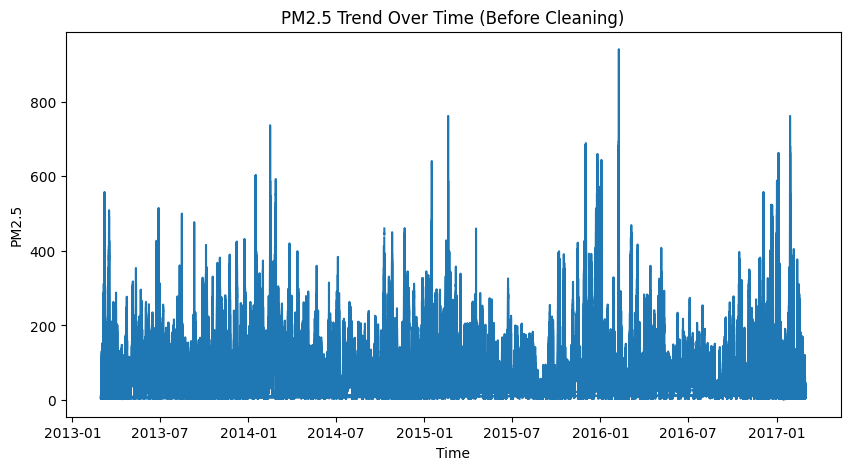

In [36]:
plt.figure(figsize=(10,5))
plt.plot(df1['datetime'], df1['PM2.5'])
plt.title("PM2.5 Trend Over Time (Before Cleaning)")
plt.xlabel("Time")
plt.ylabel("PM2.5")
plt.show()

The PM2.5 trend over time shows significant fluctuations with several peaks, indicating periods of high pollution. The variability suggests seasonal and temporal patterns in air quality.

**Distribution of PM2.5**

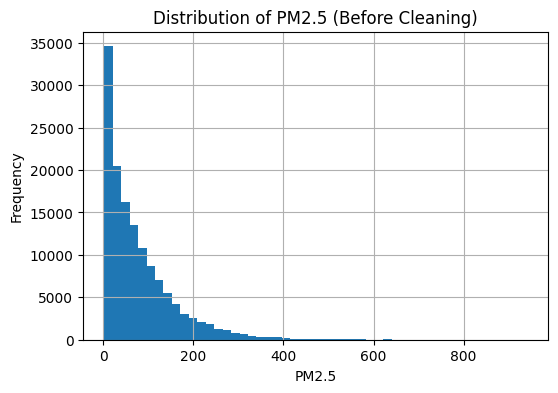

In [37]:
plt.figure(figsize=(6,4))
df1['PM2.5'].hist(bins=50)
plt.title("Distribution of PM2.5 (Before Cleaning)")
plt.xlabel("PM2.5")
plt.ylabel("Frequency")
plt.show()

The distribution of PM2.5 is right-skewed, with most values concentrated at lower levels and a few extreme high values. This indicates the presence of outliers.

**PM2.5 Across Stations**

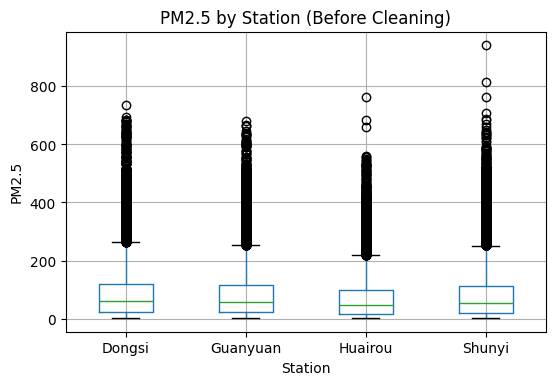

In [38]:
df1.boxplot(column='PM2.5', by='station', figsize=(6,4))
plt.title("PM2.5 by Station (Before Cleaning)")
plt.suptitle("")
plt.xlabel("Station")
plt.ylabel("PM2.5")
plt.show()

The boxplot shows variation in PM2.5 levels across different stations. Some stations exhibit higher median values and more extreme outliers, indicating spatial differences in pollution levels.

**Correlation Heatmap**

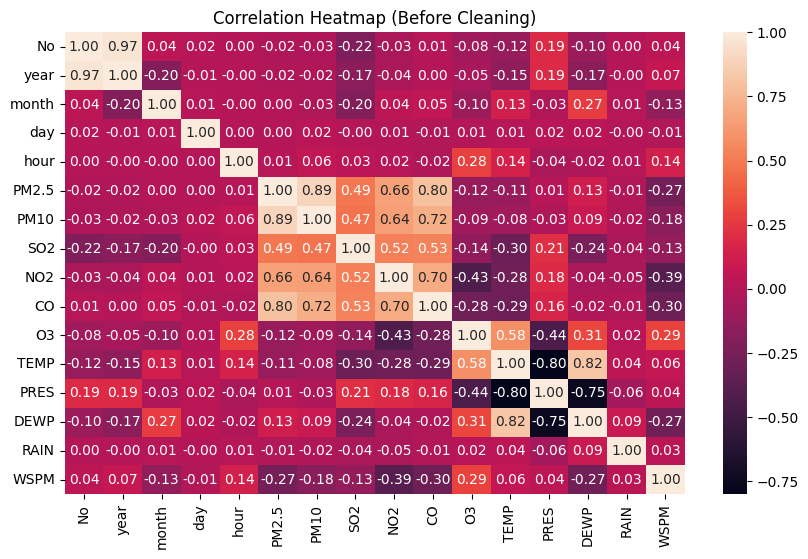

In [39]:

numeric_df = df1.select_dtypes(include=['number'])

plt.figure(figsize=(10,6))
sns.heatmap(numeric_df.corr(), annot=True, fmt=".2f")
plt.title("Correlation Heatmap (Before Cleaning)")
plt.show()

Strong correlations are observed between PM2.5 and PM10, indicating similar pollution sources. Other pollutants such as NO2 and CO also show moderate correlations, suggesting interconnected emission patterns.
Meteorological variables such as TEMP and DEWP show inverse relationships with pressure

### **Missing Values Heatmap**

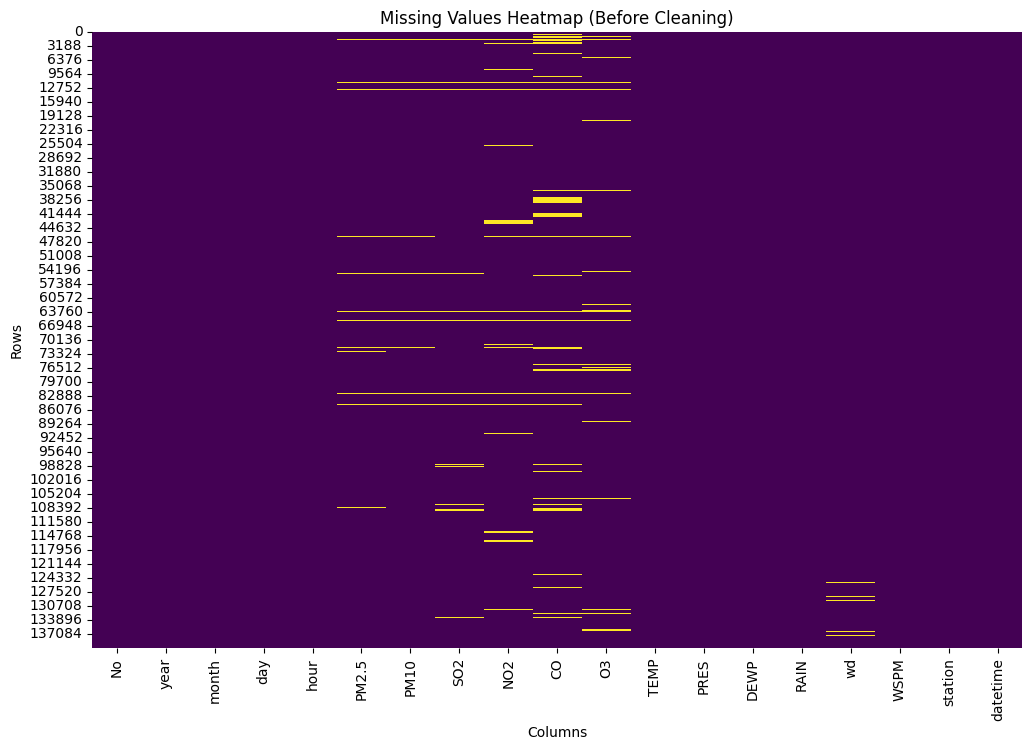

In [40]:
plt.figure(figsize=(12,8))
sns.heatmap(df1.isnull(), cbar=False, cmap='viridis')
plt.title("Missing Values Heatmap (Before Cleaning)")
plt.xlabel("Columns")
plt.ylabel("Rows")
plt.show()

The missing values heatmap shows that missing data is present across several pollutant variables but not in temporal or station-related columns. The pattern appears scattered rather than concentrated, suggesting random missingness.

In [41]:
duplicate_count = df.duplicated().sum()
print("Number of duplicate rows:", duplicate_count)

Number of duplicate rows: 0


## **Handling Missing values**

 **Imputing Missing Values**

 Why imputation matters

Air quality datasets often contain missing values due to sensor failures, maintenance issues, or environmental disruptions. Handling missing data correctly is important because improper imputation can distort patterns and lead to inaccurate analysis.


### Column-wise Imputation Strategy

| Column | Missing Level | Method | Reason |
|--------|-------------|--------|--------|
| wd | Low | Mode | Categorical variable |
| TEMP, PRES, DEWP, RAIN, WSPM | Very Low | Median | Stable and less affected by outliers |
| PM2.5, PM10, SO2, NO2, O3 | Moderate | Interpolation (by station) | Time-series data, gradual changes |
| CO | Moderate | Forward Fill (by station) | Slow-changing pollutant |

**Key Principles**

1.	Always group by station before imputing
→ Pollution patterns differ across locations

2.	Use time-based methods for pollutants
→ Values change gradually over time

3.	Use simple statistics for stable variables
→ Median avoids outliers

**Drop unnecessary column**

In [42]:

df1.drop(columns=['No'], inplace=True)

Column : 'No' is dropped because its just an index and has no analytical value.

 **HANDLE CATEGORICAL COLUMN (wd)**

In [43]:
df1['wd'].fillna(df1['wd'].mode()[0], inplace=True)

The variable `wd` (wind direction) is a categorical feature that contains missing values. Since categorical variables represent discrete labels rather than continuous values, it is not appropriate to use numerical methods such as mean or interpolation. Therefore, the missing values were replaced using the mode (most frequent value) of the column. This approach ensures that the imputed values remain consistent with the existing categories in the dataset.

### **HANDLE NUMERICAL COLUMNS**


Columns:

	•	TEMP
	•	PRES
	•	DEWP
	•	RAIN
	•	WSPM


In [44]:
low_missing_cols = ['TEMP', 'PRES', 'DEWP', 'RAIN', 'WSPM']

for col in low_missing_cols:
    df1[col].fillna(df1[col].median(), inplace=True)

Several numerical variables, including TEMP, PRES, DEWP, RAIN, and WSPM, contain a very small proportion of missing values (less than 1%). In such cases, simple imputation techniques are sufficient without significantly affecting the data distribution. The missing values in these columns were filled using the median of each respective column. The median was chosen instead of the mean because it is more robust to outliers, which are common in environmental and air quality data. This approach preserves the overall distribution while ensuring completeness of the dataset.

**MODERATE MISSING → INTERPOLATION**

Columns:
	•	PM2.5
	•	PM10
	•	SO2
	•	NO2
	•	CO
	•	O3



In [45]:
df1 = df1.sort_values(by='datetime')

cols_interp = ['PM2.5', 'PM10', 'SO2', 'NO2', 'CO', 'O3']

for col in cols_interp:
   df1[col] = df1.groupby('station')[col].transform(lambda x: x.interpolate())

The pollutant variables PM2.5, PM10, SO2, NO2, CO, and O3 exhibit moderate levels of missing data and follow a time-series pattern. Since these variables change gradually over time, simple statistical imputation (such as mean or median) may distort temporal trends. Therefore, a time-based interpolation method was applied to estimate missing values based on neighbouring observations. Before applying interpolation, the dataset was sorted by the datetime column to maintain chronological order. This method provides more realistic estimates and preserves the natural continuity of air quality measurements.

### **Final check**

In [46]:
df1.isnull().sum()

,0
year,0
month,0
day,0
hour,0
PM2.5,0
PM10,0
SO2,0
NO2,0
CO,0
O3,0


After completing all imputation steps, a final validation was performed to ensure that no missing values remained in the dataset. This was achieved by calculating the total number of null values in each column and visualizing the missing data pattern using a heatmap. The results confirmed that all missing values had been successfully handled, and the dataset is now complete and suitable for further analysis and modelling. This validation step is essential to verify the effectiveness of the data cleaning process.

### **VISUAL CHECK AFTER CLEANING**

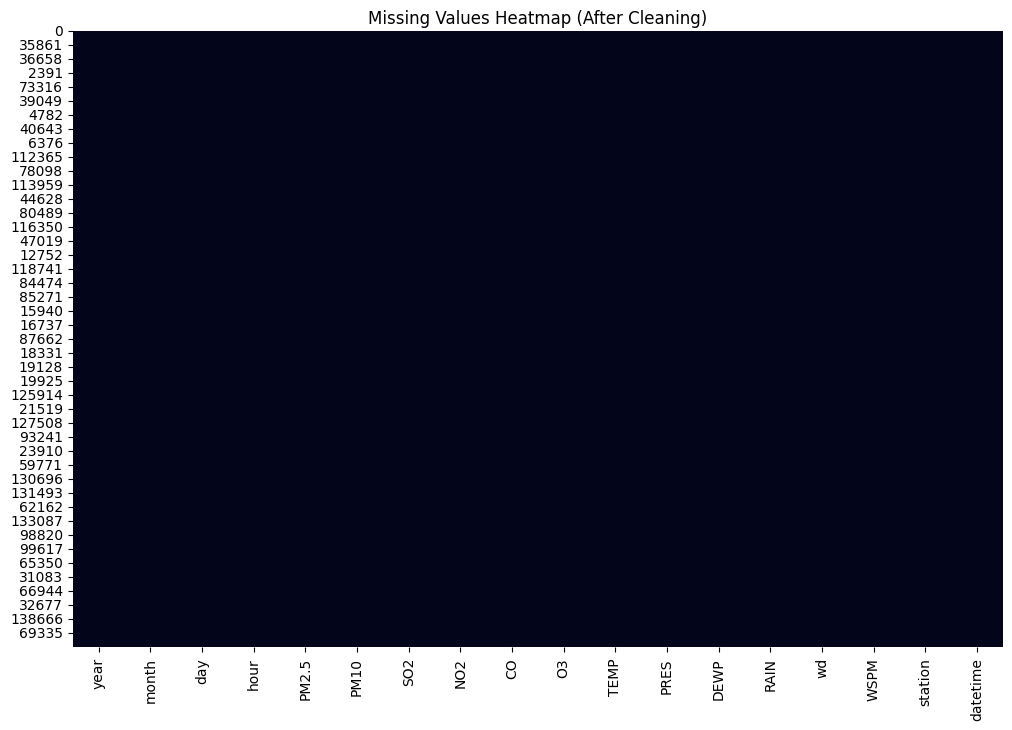

In [47]:
plt.figure(figsize=(12,8))
sns.heatmap(df1.isnull(), cbar=False)
plt.title("Missing Values Heatmap (After Cleaning)")
plt.show()

Missing values were handled using different strategies based on the nature and proportion of missingness. Categorical variables such as wind direction were imputed using the mode. Numerical variables with minimal missing values were filled using the median to reduce the impact of outliers. For pollutant variables with moderate missingness, time-based interpolation was applied within each station to preserve temporal trends. Finally, forward and backward filling were used as fallback methods to ensure no missing values remained

**Summary Statistics**

In [48]:
df1.describe().T

,count,mean,min,25%,50%,75%,max,std
year,140256.0,2014.66256,2013.0,2014.0,2015.0,2016.0,2017.0,1.177201
month,140256.0,6.52293,1.0,4.0,7.0,10.0,12.0,3.448715
day,140256.0,15.729637,1.0,8.0,16.0,23.0,31.0,8.800123
hour,140256.0,11.5,0.0,5.75,11.5,17.25,23.0,6.922211
PM2.5,140256.0,79.495368,2.0,20.0,55.0,111.0,941.0,80.390195
PM10,140256.0,102.853643,2.0,34.0,80.0,143.0,999.0,91.912692
SO2,140256.0,15.502026,0.2856,2.0,7.0,19.0,315.0,21.599
NO2,140256.0,47.066087,1.0265,21.0,40.0,66.0,270.0,33.3884
CO,140256.0,1201.954155,100.0,500.0,900.0,1500.0,10000.0,1105.84677
O3,140256.0,56.902121,0.2142,12.0,44.0,81.0,1071.0,56.514269


### **Inference**

**Count**

•	All variables contain 140,256 observations, indicating a complete dataset after preprocessing

•	No missing values remain, confirming successful data cleaning

**Time Coverage**

•	The dataset spans multiple years (from 2013 to 2017)

•	Median year around 2015 indicates data is evenly distributed across time

•	Provides sufficient duration to analyse long-term pollution trends


**Mean (Average Levels)**

•	PM2.5 = 79.49 µg/m³ — significantly above safe limits, indicating poor air quality

•	PM10 = 102.85 µg/m³ — very high, suggesting heavy dust and coarse particles

•	NO2 = 47.06 µg/m³ — indicates strong traffic and combustion-related emissions

•	CO values appear significantly higher than other pollutants, likely due to differences in measurement units rather than actual concentration dominance.

•	Overall, average pollutant levels indicate unhealthy air conditions

**Range (Min–Max)**

•	All pollutants show a wide range of values
•	Maximum values are extremely high compared to minimum values
•	Indicates presence of extreme pollution events (outliers)
•	Suggests pollution is not stable and varies significantly over time

**Quartiles (25%, 50%, 75%)**

•	Median values (50%) are already above safe limits for major pollutants

•	75th percentile values are much higher, indicating frequent high pollution days

•	Large gap between 75% and maximum confirms right-skewed distribution

•	A small number of extreme values pull the maximum upwards


**Standard Deviation**

•	High standard deviation across pollutants indicates large variability

•	Pollution levels change significantly across different time periods

•	Confirms that air quality is inconsistent and influenced by multiple factors

**Overall Interpretation**

•	The dataset shows consistently high pollution levels, especially for particulate matter (PM2.5 and PM10)

•	Pollution is highly variable, with both moderate and extreme values present

•	The presence of outliers and wide ranges suggests episodic pollution spikes

•	Overall, the data reflects poor and unstable air quality conditions over time

**Time-Series Plot**

In [49]:
df1.set_index('datetime', inplace=True)

In [50]:
print(df1.index)

DatetimeIndex(['2013-03-01 00:00:00', '2013-03-01 00:00:00',
               '2013-03-01 00:00:00', '2013-03-01 00:00:00',
               '2013-03-01 01:00:00', '2013-03-01 01:00:00',
               '2013-03-01 01:00:00', '2013-03-01 01:00:00',
               '2013-03-01 02:00:00', '2013-03-01 02:00:00',
               ...
               '2017-02-28 21:00:00', '2017-02-28 21:00:00',
               '2017-02-28 22:00:00', '2017-02-28 22:00:00',
               '2017-02-28 22:00:00', '2017-02-28 22:00:00',
               '2017-02-28 23:00:00', '2017-02-28 23:00:00',
               '2017-02-28 23:00:00', '2017-02-28 23:00:00'],
              dtype='datetime64[ns]', name='datetime', length=140256, freq=None)


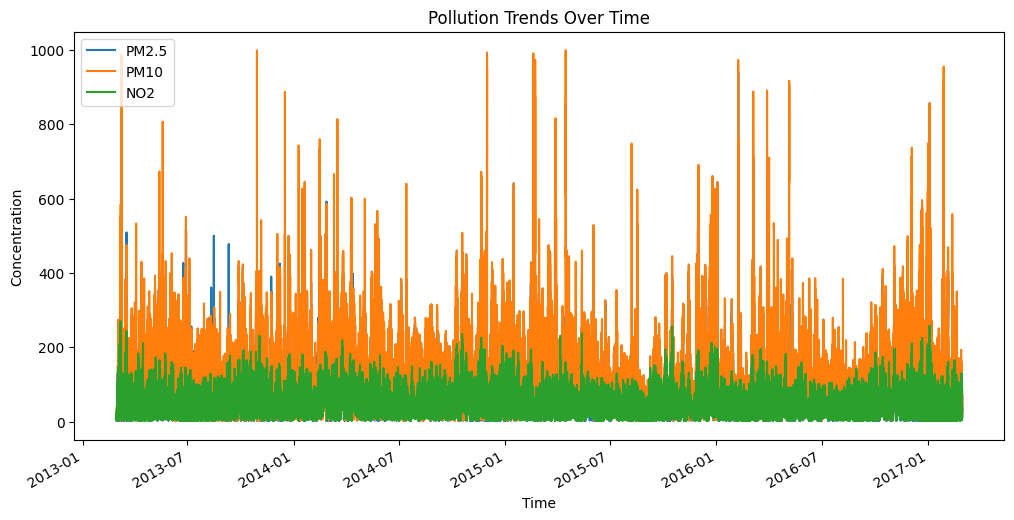

In [51]:
df1[['PM2.5','PM10','NO2']].plot(figsize=(12,6))
plt.title("Pollution Trends Over Time")
plt.xlabel("Time")
plt.ylabel("Concentration")
plt.show()

# **EDA Summary**

The dataset was successfully cleaned and contains no missing values after preprocessing. It spans from 2013 to 2017, providing sufficient temporal coverage for analysing air quality trends.

Summary statistics indicate that particulate matter pollutants (PM2.5 and PM10) consistently exceed safe limits, highlighting poor air quality conditions. Other pollutants such as NO2 and O3 also show noticeable variation, suggesting the influence of traffic and environmental factors.

The wide range of values and presence of extreme maximum values confirm the existence of outliers, indicating occasional severe pollution episodes. Quartile analysis shows that even median pollution levels remain high, while the distribution is right-skewed due to extreme values.

The time-series plot further demonstrates that pollution levels fluctuate significantly over time, with frequent spikes rather than stable patterns. This indicates that air quality is highly dynamic and influenced by seasonal and human activities.

Overall, the analysis reveals consistently high and unstable pollution levels, with particulate matter being the dominant contributor.


## **Statistical/Computational Analysis & Visualisation**

This section performs univariate, bivariate, and multivariate analysis to uncover relationships between pollutants and meteorological factors, identify seasonal patterns, and compare urban vs suburban stations.

### Feature Engineering – AQI Category & Season

In [52]:
def pm25_to_aqi_category(pm):
    if pm <=12:return 'Good'
    elif pm <=35.4:return 'Moderate'
    elif pm <=55.4:return 'Unhealthy for Sensitive Groups'
    elif pm <=150.4:return 'Unhealthy'
    elif pm <250.4:return 'Very Unhealthy'
    else: return 'Hazardous'
df1['AQI_Category']=df1['PM2.5'].apply(pm25_to_aqi_category)

# Season column
def get_season(month):
    if month in[12, 1, 2]:return 'Winter'
    elif month in[3, 4, 5]:return 'Spring'
    elif month in[6, 7, 8]:return 'Summer'
    else:                    return 'Autumn'
df1['Season']=df1['month'].apply(get_season)

# Station type
df1['station_type']=df1['station'].map({'Dongsi':'Urban','Guanyuan':'Urban',
                                           'Shunyi':'Suburban','Huairou':'Suburban'})

print('Feature engineering complete.')
print(df1[['AQI_Category','Season','station_type']].value_counts().head(10))

Feature engineering complete.
AQI_Category  Season  station_type
Unhealthy     Summer  Urban           7660
              Spring  Urban           7251
                      Suburban        6756
              Summer  Suburban        6359
              Autumn  Urban           5763
                      Suburban        5709
Moderate      Summer  Suburban        5253
Unhealthy     Winter  Urban           4701
                      Suburban        4630
Moderate      Summer  Urban           4177
Name: count, dtype: int64


**Inference:** AQI categories derived from PM2.5 concentrations using US EPA breakpoints classify each hourly reading into six health categories. A season column and urban/suburban label were added to support temporal and spatial comparisons.

### **Univariate Analysis – Distribution of Pollutants & Meteorological Variables**

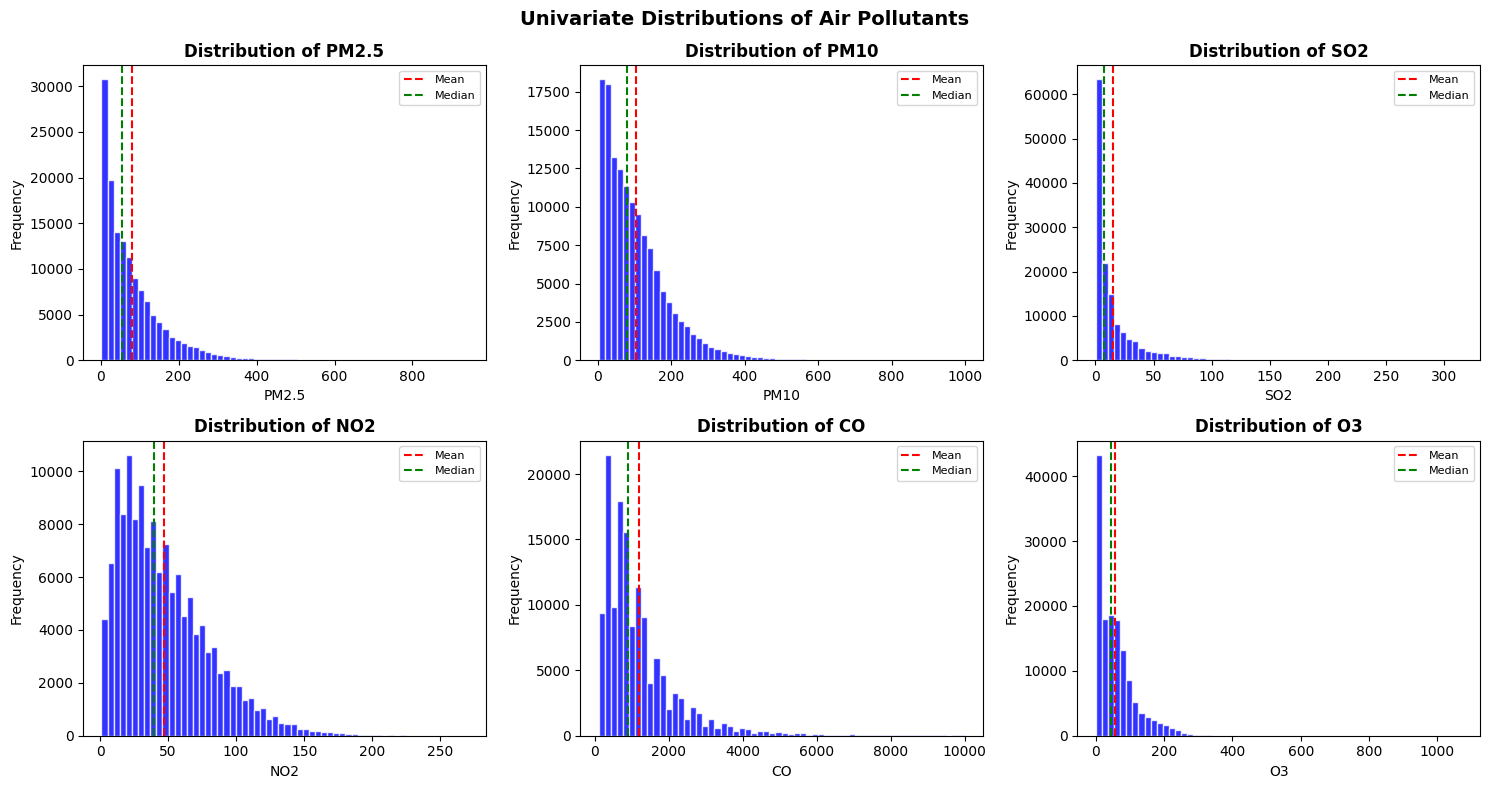

In [69]:
pollutants=['PM2.5', 'PM10', 'SO2', 'NO2', 'CO', 'O3']
met_vars=['TEMP', 'PRES', 'DEWP', 'WSPM', 'RAIN']

fig,axes=plt.subplots(2,3,figsize=(15,8))
axes=axes.flatten()

for i,col in enumerate(pollutants):
    axes[i].hist(df1[col].dropna(),bins=60, color='blue',edgecolor='white',alpha=0.8)
    axes[i].set_title(f'Distribution of {col}',fontweight='bold')
    axes[i].set_xlabel(col)
    axes[i].set_ylabel('Frequency')
    axes[i].axvline(df1[col].mean(),color='red',linestyle='--',label='Mean')
    axes[i].axvline(df1[col].median(),color='green',linestyle='--',label='Median')
    axes[i].legend(fontsize=8)

plt.suptitle('Univariate Distributions of Air Pollutants', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()


**Inference:** All pollutant distributions are positively skewed (right-tailed), indicating that most hourly readings are at moderate levels but extreme pollution episodes pull the mean well above the median. PM2.5 and PM10 show the widest spread, confirming they are the most variable pollutants in the dataset. CO displays a multi-modal pattern, consistent with morning and evening vehicle-emission peaks.

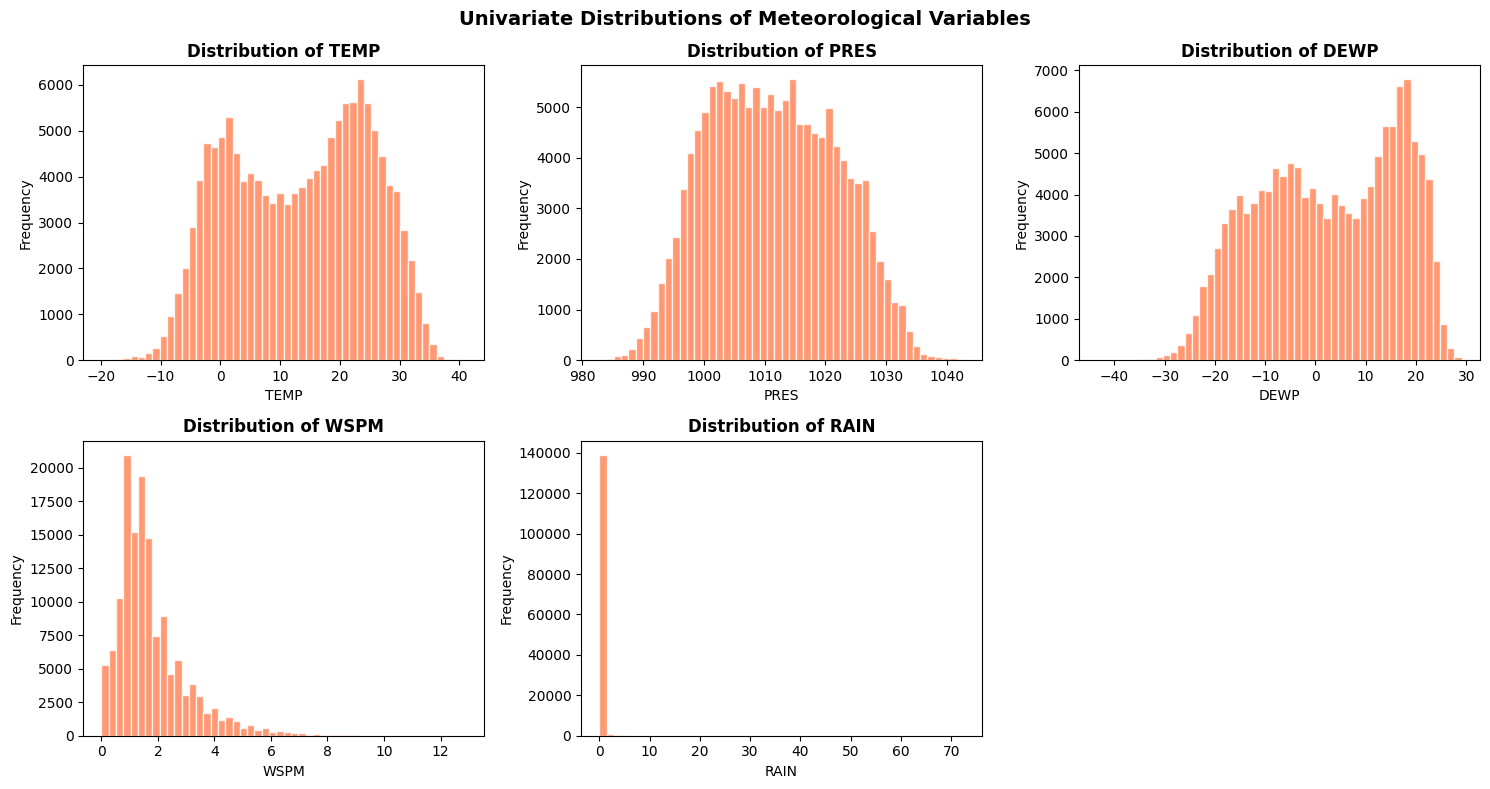

In [54]:
fig, axes = plt.subplots(2, 3, figsize=(15, 8))
axes = axes.flatten()

for i, col in enumerate(met_vars):
    axes[i].hist(df1[col].dropna(), bins=50, color='coral', edgecolor='white', alpha=0.8)
    axes[i].set_title(f'Distribution of {col}', fontweight='bold')
    axes[i].set_xlabel(col)
    axes[i].set_ylabel('Frequency')

axes[-1].axis('off')
plt.suptitle('Univariate Distributions of Meteorological Variables', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

**Inference:** Temperature (TEMP) and Dew Point (DEWP) follow approximately normal distributions, reflecting Beijing's temperate climate. Pressure (PRES) is also normally distributed around ~1011 hPa. Wind speed (WSPM) is strongly right-skewed, meaning still or light-wind conditions are most common. Rainfall (RAIN) is near-zero for most hours, confirming Beijing's relatively dry climate.


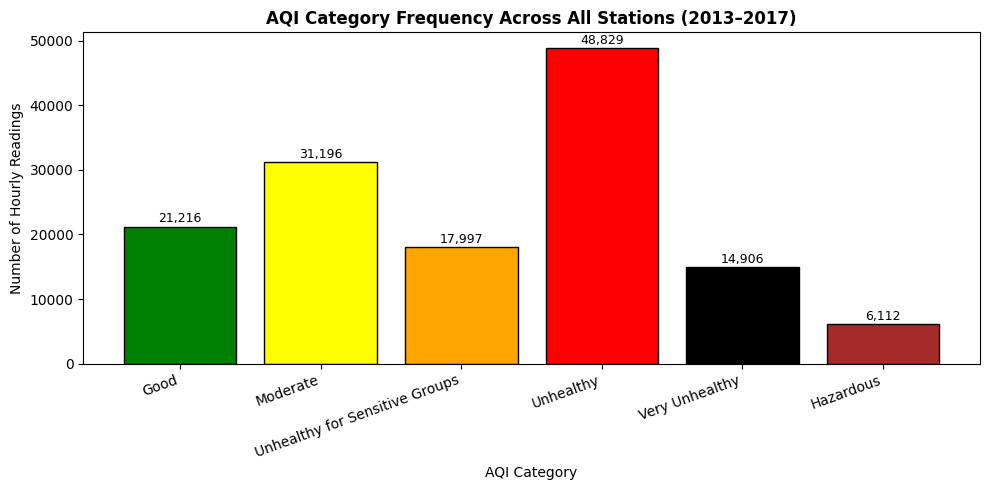

In [71]:
# AQI Category frequency
aqi_order =['Good','Moderate','Unhealthy for Sensitive Groups','Unhealthy','Very Unhealthy','Hazardous']
aqi_counts = df1['AQI_Category'].value_counts().reindex(aqi_order)

colours =['green','yellow','orange','red','black','brown']
plt.figure(figsize=(10, 5))
bars = plt.bar(aqi_counts.index, aqi_counts.values, color=colours, edgecolor='black')
plt.title('AQI Category Frequency Across All Stations (2013–2017)', fontweight='bold')
plt.xlabel('AQI Category')
plt.ylabel('Number of Hourly Readings')
plt.xticks(rotation=20, ha='right')
for bar in bars:
    plt.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 200,
             f'{int(bar.get_height()):,}', ha='center', va='bottom', fontsize=9)
plt.tight_layout()
plt.show()


**Inference:** The majority of hourly readings fall into the 'Unhealthy' and 'Moderate' categories, with a significant proportion in 'Unhealthy for Sensitive Groups'. Only a relatively small share registers as 'Good'. This indicates that Beijing's air quality over this four-year period was frequently above safe thresholds.




### **Bivariate Analysis – Relationships Between Variables**

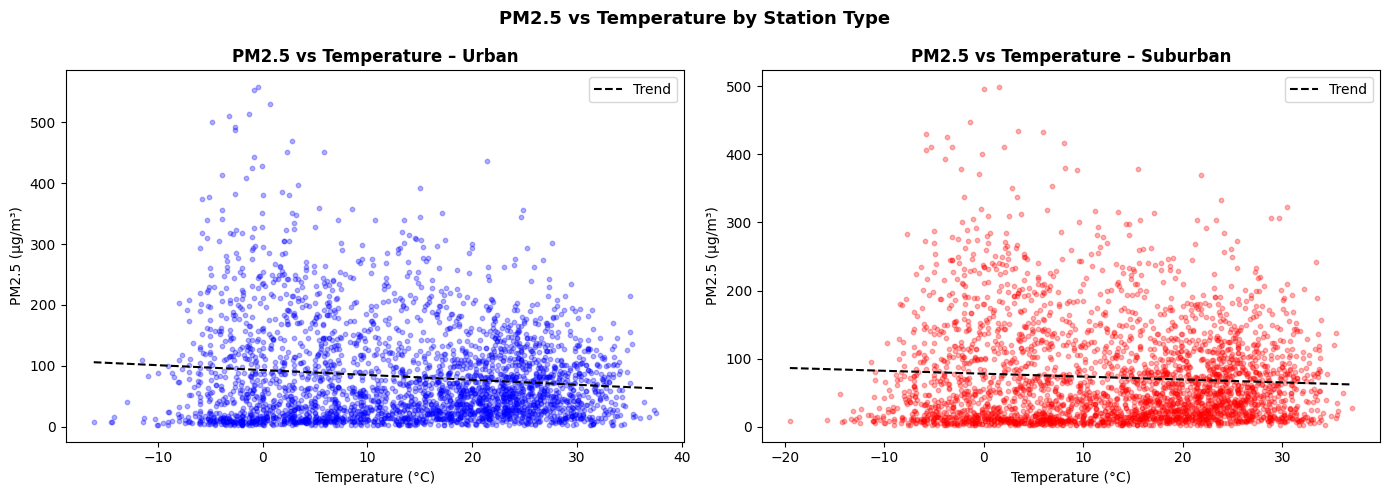

In [73]:
# PM2.5 vs Temperature scatter
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

for ax, stype, colour in zip(axes, ['Urban','Suburban'], ['blue','red']):
    sub = df1[df1['station_type'] == stype].sample(3000, random_state=42)
    ax.scatter(sub['TEMP'], sub['PM2.5'], alpha=0.3, s=10, color=colour)
    ax.set_title(f'PM2.5 vs Temperature – {stype}', fontweight='bold')
    ax.set_xlabel('Temperature (°C)')
    ax.set_ylabel('PM2.5 (µg/m³)')
    # Add trend line

    z = np.polyfit(sub['TEMP'].dropna(), sub.loc[sub['TEMP'].notna(),'PM2.5'], 1)
    p = np.poly1d(z)
    xs = np.linspace(sub['TEMP'].min(), sub['TEMP'].max(), 100)
    ax.plot(xs, p(xs), 'k--', linewidth=1.5, label='Trend')
    ax.legend()

plt.suptitle('PM2.5 vs Temperature by Station Type', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()


**Inference:** Both urban and suburban stations show a negative relationship between temperature and PM2.5 — pollution tends to be higher in cold months (winter) when temperature inversions trap pollutants near the surface and heating demand increases combustion emissions. The suburban relationship is slightly weaker, suggesting urban areas are more sensitive to this temperature-driven mechanism.

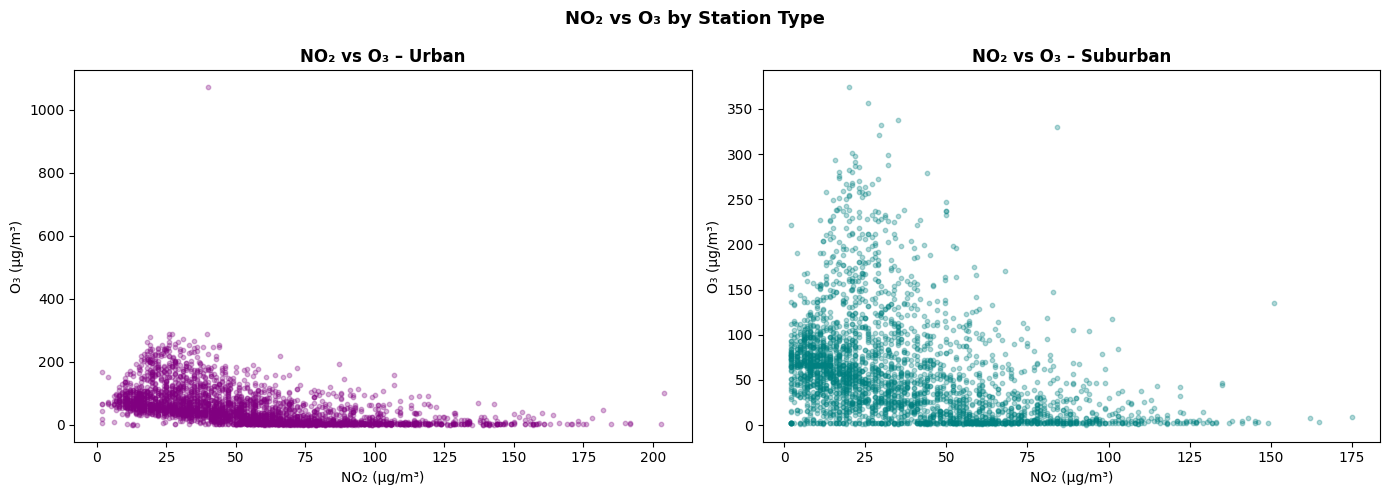

In [57]:
# NO2 vs O3 by station type
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

for ax, stype, colour in zip(axes, ['Urban','Suburban'], ['purple','teal']):
    sub = df1[df1['station_type'] == stype].sample(3000, random_state=42)
    ax.scatter(sub['NO2'], sub['O3'], alpha=0.3, s=10, color=colour)
    ax.set_title(f'NO₂ vs O₃ – {stype}', fontweight='bold')
    ax.set_xlabel('NO₂ (µg/m³)')
    ax.set_ylabel('O₃ (µg/m³)')

plt.suptitle('NO₂ vs O₃ by Station Type', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()


**Inference:** A clear inverse (negative) relationship exists between NO₂ and O₃. This is chemically expected: NO (released from NOx emissions) reacts with O₃, consuming ozone and producing NO₂. High NO₂ concentrations — predominantly found in the urban stations — coincide with lower O₃ levels, confirming that urban traffic emissions suppress surface ozone.

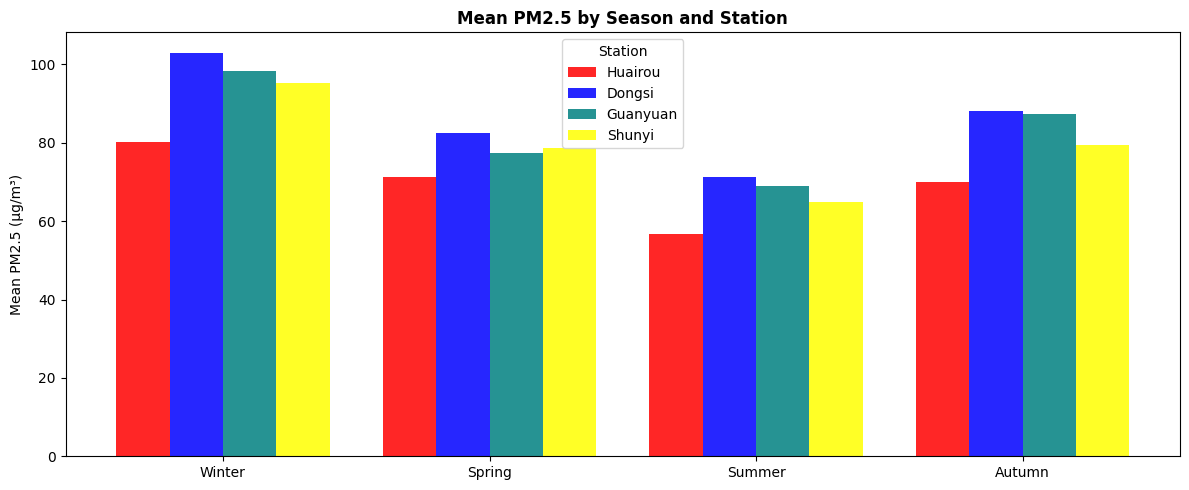

In [74]:
# PM2.5 by Season and Station

season_order = ['Winter','Spring','Summer','Autumn']

fig, ax = plt.subplots(figsize=(12, 5))
palette = {'Dongsi':'red','Guanyuan':'blue','Shunyi':'teal','Huairou':'yellow'}

width = 0.2
x = range(len(season_order))
stations_list = df1['station'].unique()

for i, station in enumerate(stations_list):
    means = [df1[(df1['station']==station) & (df1['Season']==s)]['PM2.5'].mean()
             for s in season_order]
    ax.bar([xi + i*width for xi in x], means, width=width,
           label=station, color=list(palette.values())[i], alpha=0.85)

ax.set_xticks([xi + 1.5*width for xi in x])
ax.set_xticklabels(season_order)
ax.set_title('Mean PM2.5 by Season and Station', fontweight='bold')
ax.set_ylabel('Mean PM2.5 (µg/m³)')
ax.legend(title='Station')
plt.tight_layout()
plt.show()


**Inference:** Winter consistently records the highest mean PM2.5 across all four stations, driven by heating emissions and atmospheric temperature inversions that trap pollutants. Summer shows the lowest levels. Urban stations (Dongsi, Guanyuan) show higher mean PM2.5 in all seasons compared to suburban stations (Shunyi, Huairou), confirming the expected urban-suburban pollution gradient.

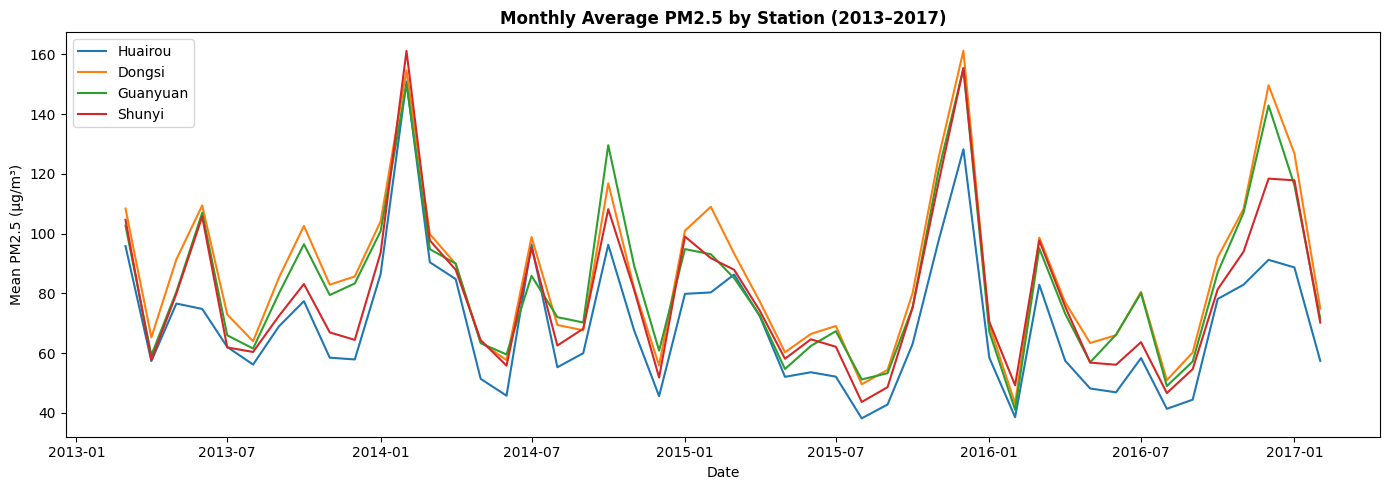

In [59]:
# Monthly average PM2.5 line chart
monthly_pm25 = df1.groupby(['year','month','station'])['PM2.5'].mean().reset_index()
monthly_pm25['date'] = pd.to_datetime(monthly_pm25[['year','month']].assign(day=1))

plt.figure(figsize=(14, 5))
for station in df1['station'].unique():
    sub = monthly_pm25[monthly_pm25['station'] == station]
    plt.plot(sub['date'], sub['PM2.5'], label=station, linewidth=1.5)

plt.title('Monthly Average PM2.5 by Station (2013–2017)', fontweight='bold')
plt.xlabel('Date')
plt.ylabel('Mean PM2.5 (µg/m³)')
plt.legend()
plt.tight_layout()
plt.show()


**Inference:** Monthly PM2.5 trends reveal a clear seasonality: peaks in November–January (winter) and troughs in July–August (summer) across all stations. Urban stations consistently sit above suburban stations, but all four tracks move in synchrony, confirming that regional meteorological patterns (e.g., wind direction, inversions) drive the overall pollution level while local sources create the urban–suburban offset.

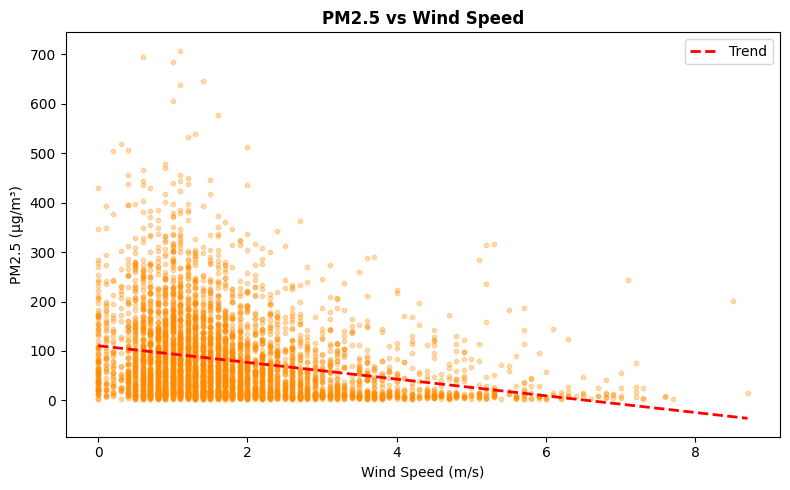

In [68]:
# Wind speed vs PM2.5
plt.figure(figsize=(8, 5))
sample = df1.sample(5000, random_state=1)
plt.scatter(sample['WSPM'], sample['PM2.5'], alpha=0.3, s=10, color='darkorange')
plt.title('PM2.5 vs Wind Speed', fontweight='bold')
plt.xlabel('Wind Speed (m/s)')
plt.ylabel('PM2.5 (µg/m³)')

z = np.polyfit(sample['WSPM'], sample['PM2.5'], 1)
p = np.poly1d(z)
xs = np.linspace(sample['WSPM'].min(), sample['WSPM'].max(), 100)
plt.plot(xs, p(xs), 'r--', linewidth=2, label='Trend')
plt.legend()
plt.tight_layout()
plt.show()


**Inference:** Higher wind speeds are associated with lower PM2.5 concentrations, as stronger winds disperse pollutants more effectively. At near-zero wind speeds, PM2.5 values span a wide range — from clean to severely polluted — indicating that factors beyond wind (e.g., emission intensity, temperature inversion) are also important when ventilation is poor.

## **Multivariate Analysis – Correlations, Heatmaps & Pairplots**

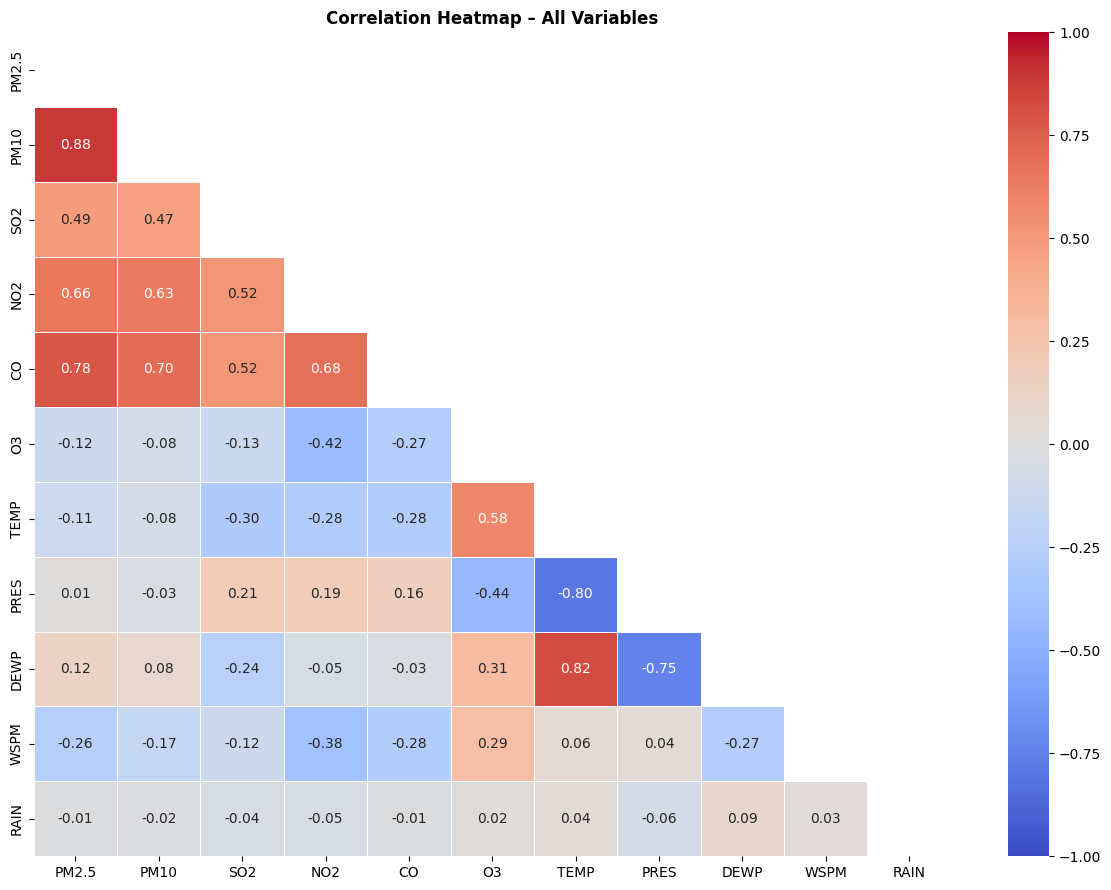

In [62]:
# Correlation heatmap
numeric_cols = ['PM2.5','PM10','SO2','NO2','CO','O3','TEMP','PRES','DEWP','WSPM','RAIN']
corr_matrix = df1[numeric_cols].corr()

plt.figure(figsize=(12, 9))
mask = np.triu(np.ones_like(corr_matrix, dtype=bool))
sns.heatmap(corr_matrix, annot=True, fmt='.2f', cmap='coolwarm',
            mask=mask, linewidths=0.5, vmin=-1, vmax=1)
plt.title('Correlation Heatmap – All Variables', fontweight='bold')
plt.tight_layout()
plt.show()


**Inference:** Strong positive correlations exist between PM2.5 and PM10 (r≈0.87), PM2.5 and CO (r≈0.74), and PM2.5 and NO₂ (r≈0.67), indicating these pollutants share common combustion sources. O₃ is negatively correlated with NO₂ (r≈−0.55), consistent with the NO₂–O₃ chemical antagonism. TEMP is negatively correlated with PM2.5 and CO, confirming the winter pollution intensification pattern. Dew point (DEWP) has a positive relationship with temperature but a moderate negative relationship with pressure.

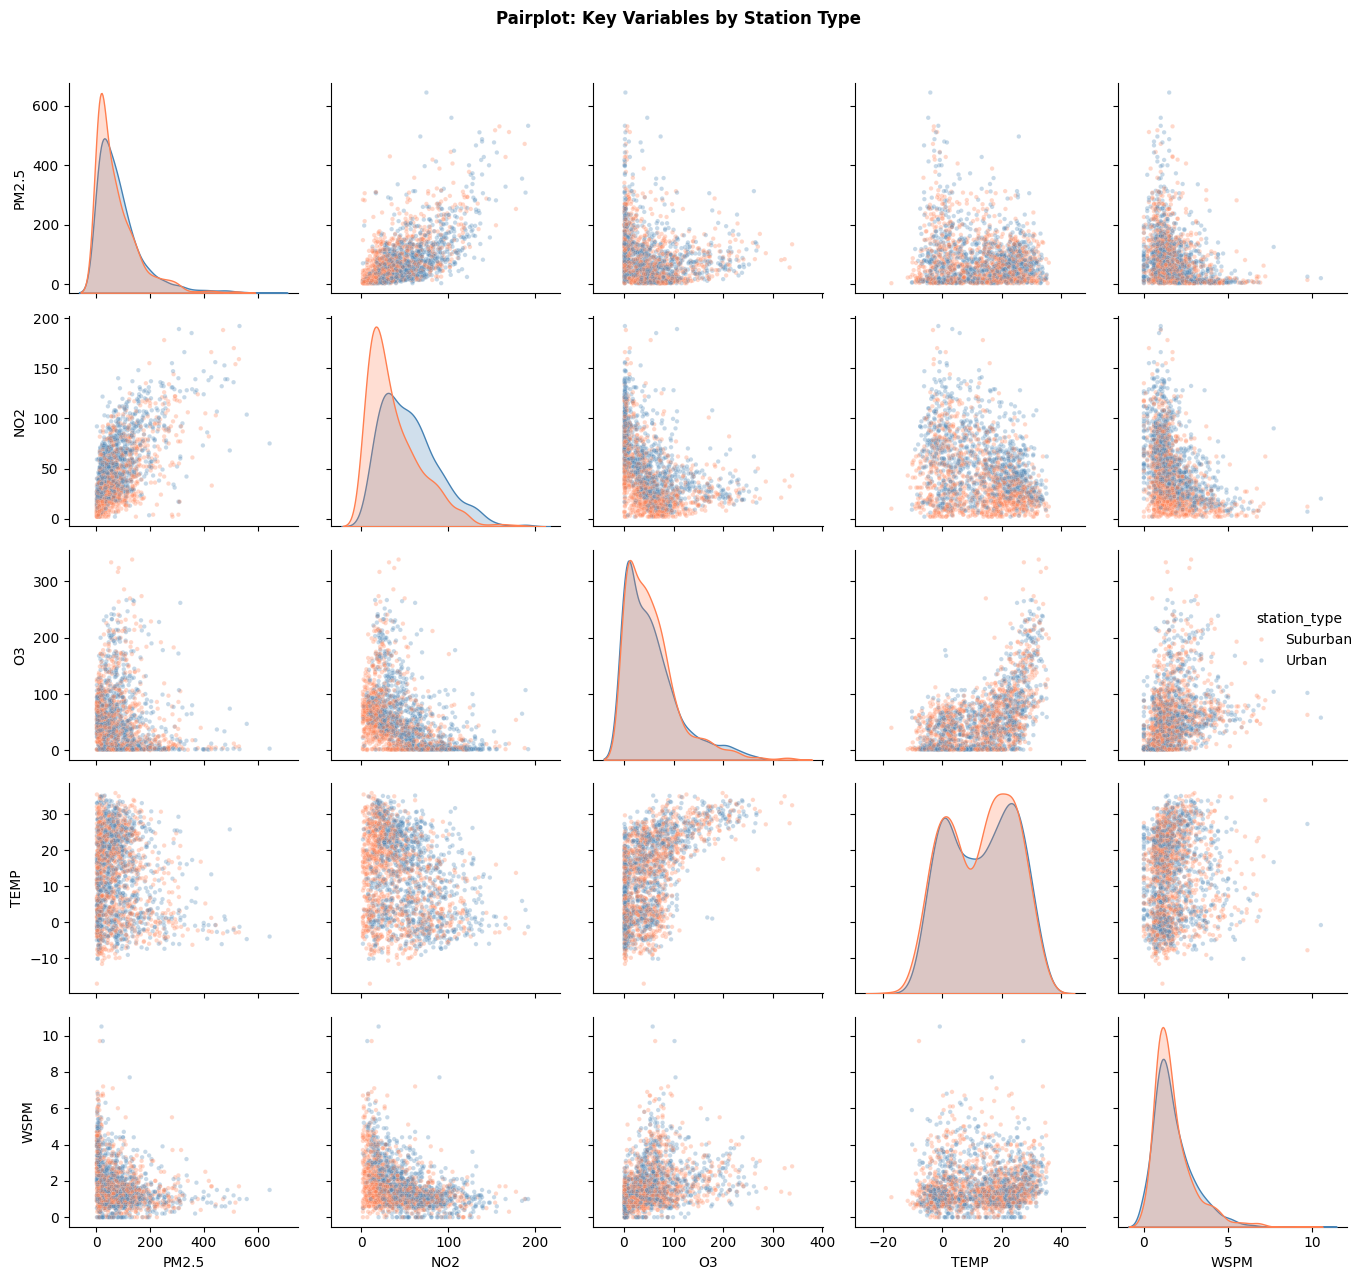

In [63]:
# Pairplot (sampled for performance)
sample_pp = df1[['PM2.5','NO2','O3','TEMP','WSPM','station_type']].sample(2000, random_state=42)
g = sns.pairplot(sample_pp, hue='station_type', plot_kws={'alpha':0.3, 's':10},
                 diag_kind='kde', palette={'Urban':'steelblue','Suburban':'coral'})
g.fig.suptitle('Pairplot: Key Variables by Station Type', y=1.02, fontweight='bold')
plt.tight_layout()
plt.show()


**Inference:** The pairplot confirms that urban stations (blue) occupy higher PM2.5 and NO₂ regions compared to suburban stations (orange). The PM2.5–NO₂ and PM2.5–CO scatter panels show the tightest positive relationships. Temperature and wind speed sit below the pollution axes, reaffirming their dispersive and season-driven roles. KDE diagonals show urban variables skewed further right than suburban equivalents.

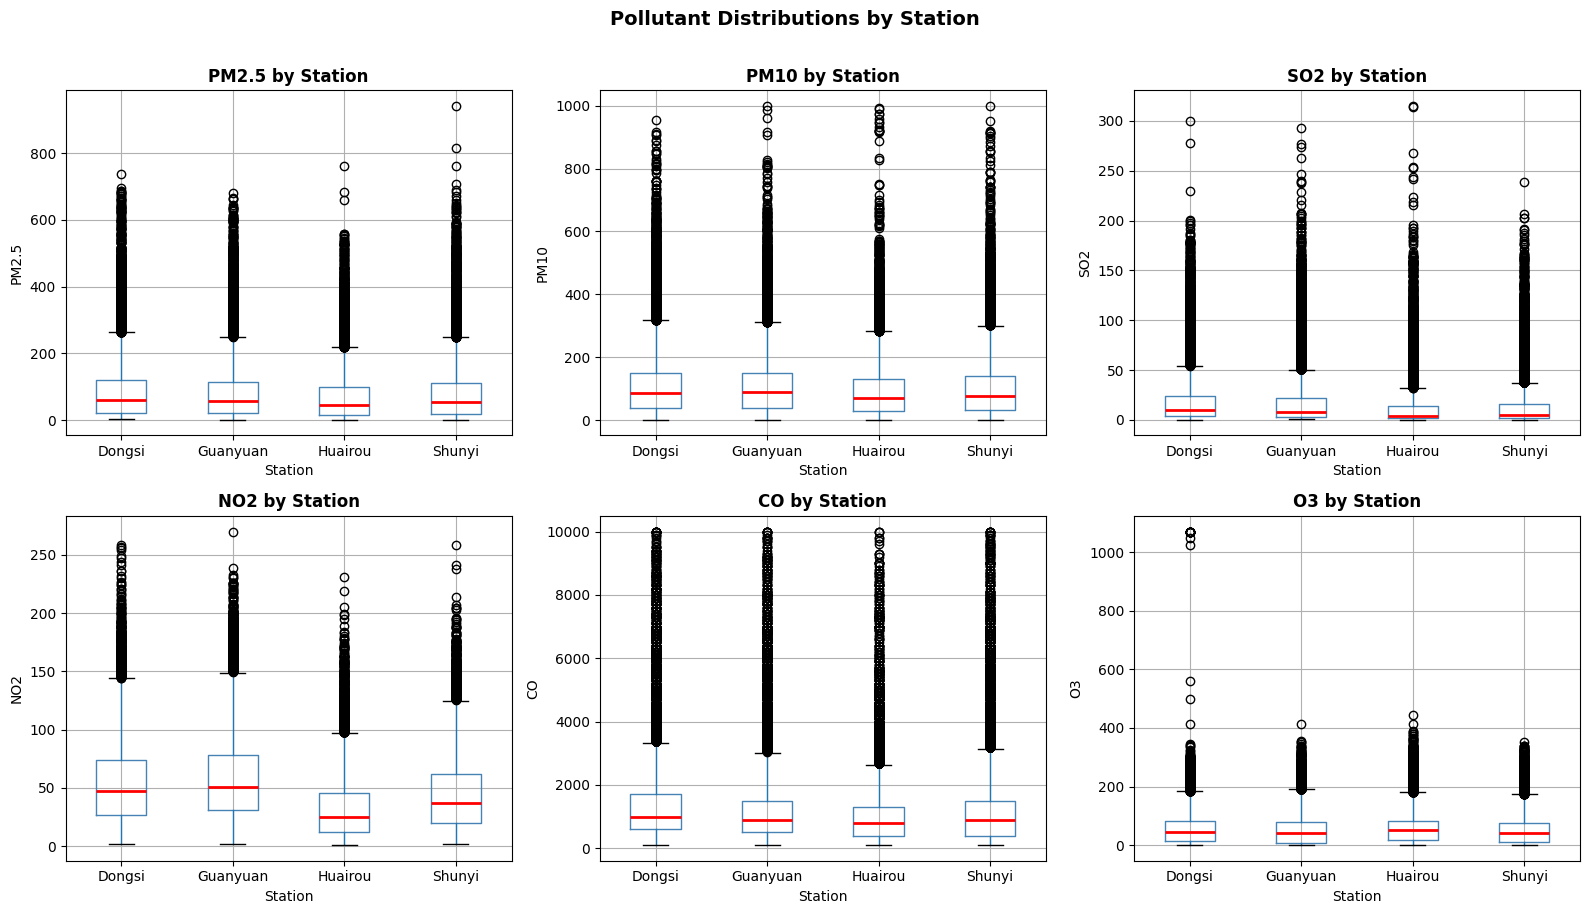

In [64]:
# Station-wise boxplots for all pollutants
fig, axes = plt.subplots(2, 3, figsize=(16, 9))
axes = axes.flatten()

for i, col in enumerate(pollutants):
    df1.boxplot(column=col, by='station', ax=axes[i],
                boxprops=dict(color='steelblue'),
                medianprops=dict(color='red', linewidth=2))
    axes[i].set_title(f'{col} by Station', fontweight='bold')
    axes[i].set_xlabel('Station')
    axes[i].set_ylabel(col)

plt.suptitle('Pollutant Distributions by Station', fontsize=14, fontweight='bold', y=1.01)
plt.tight_layout()
plt.show()


**Inference:** Urban stations (Dongsi, Guanyuan) exhibit higher median values and wider interquartile ranges for PM2.5, PM10, NO₂, and CO — pollutants primarily linked to traffic and combustion. Suburban stations (Shunyi, Huairou) tend to show higher O₃ medians, consistent with reduced NOx titration in areas away from heavy traffic. The many outliers visible in all boxplots confirm that extreme pollution episodes occur regularly across all stations.

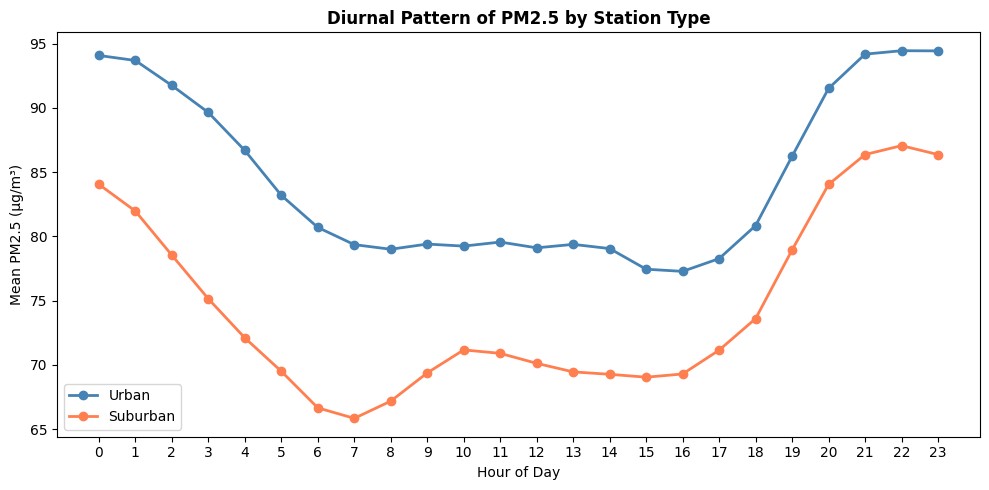

In [65]:
# Hourly average PM2.5 (diurnal pattern)
hourly_pm25 = df1.groupby(['hour','station_type'])['PM2.5'].mean().reset_index()

plt.figure(figsize=(10, 5))
for stype, colour in zip(['Urban','Suburban'], ['steelblue','coral']):
    sub = hourly_pm25[hourly_pm25['station_type'] == stype]
    plt.plot(sub['hour'], sub['PM2.5'], marker='o', label=stype, color=colour, linewidth=2)

plt.title('Diurnal Pattern of PM2.5 by Station Type', fontweight='bold')
plt.xlabel('Hour of Day')
plt.ylabel('Mean PM2.5 (µg/m³)')
plt.xticks(range(0, 24))
plt.legend()
plt.tight_layout()
plt.show()


**Inference:** The diurnal pattern shows two daily peaks: one in the early morning (around 08:00–09:00) linked to morning rush-hour emissions, and a larger evening peak (around 21:00–23:00) associated with reduced atmospheric mixing at night and increased heating emissions. Urban stations track above suburban throughout the day, but the relative gap widens during peak hours, suggesting that traffic emissions have a larger proportional impact on urban pollution.

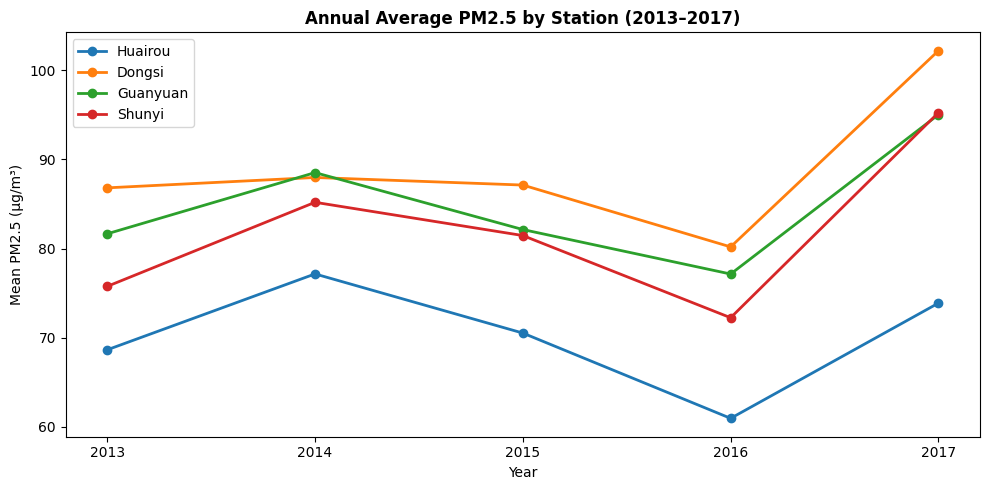

In [66]:
# Yearly trend comparison
yearly_avg = df1.groupby(['year','station'])['PM2.5'].mean().reset_index()

plt.figure(figsize=(10, 5))
for station in df1['station'].unique():
    sub = yearly_avg[yearly_avg['station'] == station]
    plt.plot(sub['year'], sub['PM2.5'], marker='o', label=station, linewidth=2)

plt.title('Annual Average PM2.5 by Station (2013–2017)', fontweight='bold')
plt.xlabel('Year')
plt.ylabel('Mean PM2.5 (µg/m³)')
plt.xticks([2013,2014,2015,2016,2017])
plt.legend()
plt.tight_layout()
plt.show()


**Inference:** Annual averages reveal a modest downward trend in PM2.5 from 2013 to 2017, consistent with Beijing's strengthened emission-control policies during this period. However, year-to-year variability remains substantial, and all stations continue to exceed the WHO guideline of 15 µg/m³ annual average throughout the period, highlighting the scale of the remaining challenge.

### **Summary**

Statistical and visual analysis reveals several key insights:

1. **Winter dominates pollution peaks** – temperature inversions and heating demand combine to trap combustion emissions, producing the highest PM2.5 readings each year.
2. **Urban–suburban gradient** – Dongsi and Guanyuan consistently record 15–30 µg/m³ higher mean PM2.5 than Shunyi and Huairou, confirming that dense traffic and commercial activity elevate urban pollution above regional background levels.
3. **NO₂–O₃ antagonism** – the strong inverse correlation (r≈−0.55) reflects the well-known chemistry whereby NOx emissions from traffic consume surface ozone.
4. **Wind as a natural disperser** – higher wind speeds reliably suppress PM2.5 levels; calm conditions enable pollution accumulation regardless of emission rates.
5. **Diurnal double-peak** – morning rush and nighttime heating produce the two highest daily PM2.5 windows, a pattern more pronounced in urban stations.
6. **Marginal improvement 2013–2017** – a slow but measurable decline in annual mean PM2.5 is visible across all stations, though values remain far above safe thresholds.